In [1]:
import sys
sys.path.insert(0, '../lib')

import glob
import os
import pickle
import datetime
import itertools

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import datasets
import numpy as np
import pandas as pd
import wandb
import scipy
import sklearn.metrics
import statsmodels.stats.multitest

import common_data
import common_plots

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = "retina"

In [3]:
pd.options.display.max_columns = 300
pd.options.display.max_rows = 350
pd.options.display.max_colwidth = 10000

In [4]:
common_plots.setup_plotting()

In [5]:
with open('04_rare_pathogen_preds.pkl', 'rb') as f:
    rare_pathogen_preds = pickle.load(f)

In [6]:
# Isolate the sample ids of the rare pathogen samples
sc_labels = pd.read_csv(common_data.SC_LABELS)
RARE_GROUPS = {
    'Gram-*; SARS-CoV-2': 'Mixed',
    'Gram-*; SARS-CoV-2; Gram+': 'Mixed',
    'Other viruses': 'Virus only',
    'Gram-*; Pseudomonas aeruginosa': 'Bacteria only',
    'Pseudomonas aeruginosa; Gram+': 'Bacteria only',
    'Other viruses; Pseudomonas aeruginosa': 'Mixed',
    'Gram-*; Other viruses; SARS-CoV-2': 'Mixed'
}

In [7]:
per_sample_data = []
for model_path, model_df in rare_pathogen_preds.items():
    for sample in model_df['sample'].unique():
        idx = model_df['sample'].eq(sample)
        assert model_df.true_label[idx].std() == 0
        n_cells = idx.sum()
        sample_info = dict(
            model_path=model_path,
            sample=sample,
            n_cells=n_cells,
            avg_pred=model_df.pred_label[idx].mean(),
            true_label=model_df.true_label[idx].iloc[0]
        )
        per_sample_data.append(sample_info)
per_sample_data = pd.DataFrame(per_sample_data)

In [8]:
per_sample_data['model'] = per_sample_data.model_path.str.split('/').str[-1]
per_sample_data['split'] = per_sample_data.model_path.str.split('/').str[-2]
per_sample_data['task'] = per_sample_data.model_path.str.split('/').str[-3]
per_sample_data = per_sample_data.drop(columns='model_path')

Check that number of cells is equal for different random initializations

In [9]:
assert np.all(per_sample_data.groupby(['sample', 'split', 'task']).n_cells.std() == 0)

Take average across random initializations

In [16]:
per_sample_data_agg = per_sample_data.groupby(['sample', 'task']).mean().reset_index()

/tmp/ipykernel_3203636/1116638396.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  per_sample_data_agg = per_sample_data.groupby(['sample', 'task']).mean().reset_index()


In [17]:
rare_heatmap = per_sample_data_agg.pivot_table(
    index='sample',
    columns='task',
    values='avg_pred'
)

In [18]:
RARE_GROUP_ORDER = ['Virus only', 'Mixed', 'Bacteria only']

In [19]:
sample_order = []
sample_borders = []
for cat in RARE_GROUP_ORDER:
    for sample in rare_heatmap.index:
        category = sc_labels.pathogen_groups[sc_labels.bal_barcode.eq(sample)].iloc[0]
        if RARE_GROUPS[category] == cat:
            sample_order.append(sample)
    sample_borders.append(len(sample_order))

In [20]:
TASKS_MAP = {
    'H_vs_G+': 'Gram+',
    'H_vs_G-': 'Other Gram–',
    'H_vs_G-_G+': 'Other Gram–; Gram+',
    'H_vs_P': 'Pseudomonas',
    'H_vs_P_COVID': 'SARS-CoV-2; Pseudomonas',
    'H_vs_eCOVID': 'Early SARS-CoV-2',
    'H_vs_eCOVID_G+': 'Early SARS-CoV-2; Gram+',
    'H_vs_lCOVID': 'Late SARS-CoV-2',
    'H_vs_lCOVID_G+': 'Late SARS-CoV-2; Gram+',
    'viral_vs_bacterial': 'Early SARS-CoV-2 vs. Bacteria only'
}

In [21]:
TASK_ORDER = [
    'H_vs_eCOVID',
    'H_vs_lCOVID',
    'H_vs_G+',
    'H_vs_P',
    'H_vs_G-',
    'H_vs_G-_G+',
    'H_vs_eCOVID_G+',
    'H_vs_lCOVID_G+',
    'H_vs_P_COVID',
    # 'viral_vs_bacterial'
]

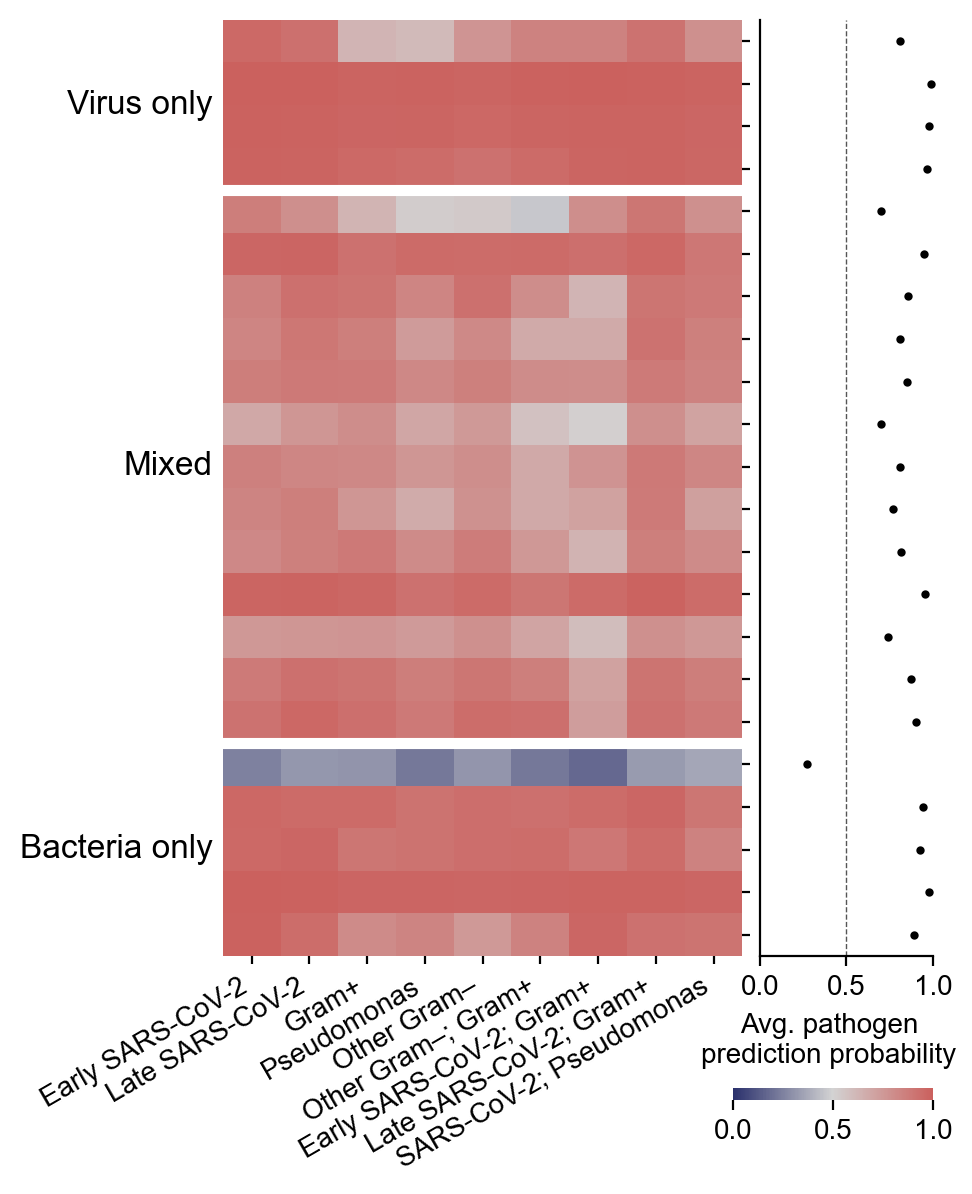

In [32]:
fig, axes = plt.subplots(figsize=(5, 6), ncols=2, sharey=True, gridspec_kw=dict(wspace=0.05, width_ratios=(3, 1)))

ax = axes[0]

pleasant_blue = '#2a306c'  # Steel Blue
pleasant_red = '#cb615e'   # Indian Red
colors = [pleasant_blue, 'lightgray', pleasant_red]
n_bins = 255
cmap = mpl.colors.LinearSegmentedColormap.from_list('custom', colors, N=n_bins)

cbar_ax = fig.add_axes((0.75, 0.08, 0.2, 0.01))

sns.heatmap(
    rare_heatmap.loc[sample_order, TASK_ORDER],
    cmap=cmap,
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=[],
    yticklabels=[],
    ax=ax,
    cbar_ax=cbar_ax,
    cbar_kws=dict(
        label='',
        orientation='horizontal',
        ticks=[0, 0.5, 1]
    ),
)

for border in sample_borders[:-1]:
    ax.axhline(y=border, c='w', lw=4)

for idx, category in enumerate(RARE_GROUP_ORDER):
    prev_y = 0
    if idx > 0:
        prev_y = sample_borders[idx - 1]
    ax.annotate(
        category,
        xy=(0, prev_y + (sample_borders[idx] - prev_y) / 2),
        xytext=(-10, 0),
        textcoords='offset pixels',
        va='center',
        ha='right',
        # rotation=90,
        size=12
    )

ax.set_yticks(np.arange(rare_heatmap.shape[0]) + 0.5)
ax.tick_params(right=True, left=False, size=3)

x_ticks = []
x_tick_labels = []
for i, task in enumerate(TASK_ORDER):
    x_ticks.append(i + 0.5)
    x_tick_labels.append(TASKS_MAP[task])

ax.set_xticks(x_ticks, labels=x_tick_labels, ha='right', rotation=30)

ax.set_xlabel('')
ax.set_ylabel('')

ax = axes[1]
ax.tick_params(left=False)
ax.axvline(0.5, c='#555', lw=0.5, ls='--')
ax.spines[['top', 'right']].set_visible(False)

avg_preds = rare_heatmap.loc[sample_order, TASK_ORDER].mean(axis=1).to_frame(name='avg_prob')
avg_preds['idx'] = np.arange(avg_preds.shape[0]) + 0.5

ax.scatter(avg_preds.avg_prob, avg_preds.idx, s=4, c='k', zorder=5, clip_on=False)
ax.set_xlim(0, 1)

ax.set_xlabel('Avg. pathogen\nprediction probability', x=0.4)
fig.subplots_adjust(top=0.98, right=0.95, bottom=0.2, left=0.24)
fig.savefig('00_plots/04b_rare_path_heatmap.pdf')

In [37]:
avg_preds = rare_heatmap.viral_vs_bacterial.to_frame(name='avg_prob')

In [38]:
avg_preds['group'] = [
    RARE_GROUPS[sc_labels.pathogen_groups[sc_labels.bal_barcode.eq(x)].iloc[0]] for x in avg_preds.index
]

/tmp/ipykernel_3203636/1751314226.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=avg_preds, x='group', y='avg_prob', order=RARE_GROUP_ORDER, ax=ax, palette=['k'])
/tmp/ipykernel_3203636/1751314226.py:29: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=avg_preds, x='group', y='avg_prob', order=RARE_GROUP_ORDER, ax=ax, palette=['k'])
/tmp/ipykernel_3203636/1751314226.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(RARE_GROUP_ORDER)


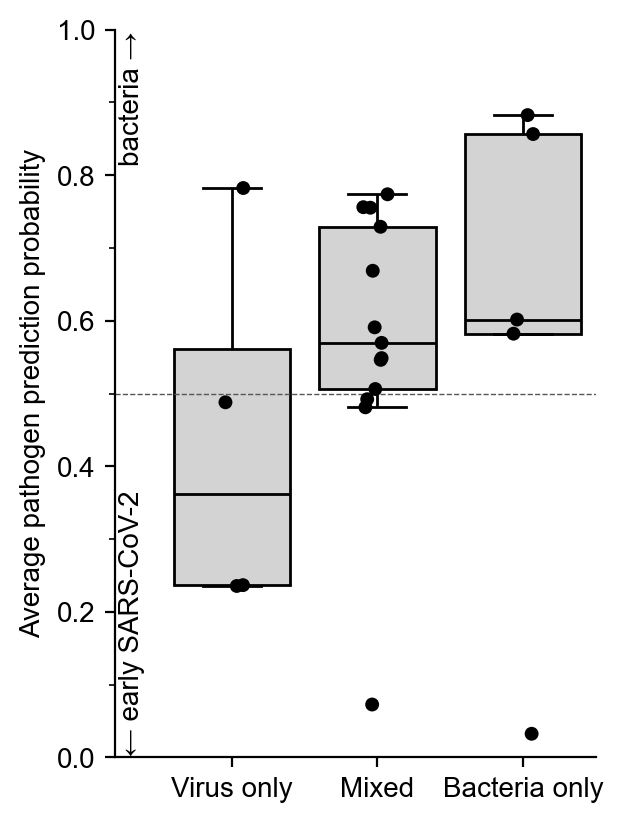

In [ ]:
fig, ax = plt.subplots(figsize=(3, 4), constrained_layout=True)

stats_results = []
for d1, d2 in itertools.combinations(RARE_GROUP_ORDER, 2):
    days1 = avg_preds.avg_prob[avg_preds.group.eq(d1)].dropna()
    days2 = avg_preds.avg_prob[avg_preds.group.eq(d2)].dropna()
    if days1.size == 0 or days2.size == 0:
        continue
    pval = scipy.stats.mannwhitneyu(days1, days2).pvalue
    stats_results.append([d1, d2, days1.size, days2.size, pval])

stats_results = pd.DataFrame(
    stats_results,
    columns=["group1", "group2", "group1_size", "group2_size", "pval"]
)
stats_results['padj'] = statsmodels.stats.multitest.fdrcorrection(stats_results.pval)[1]
stats_results_sign = stats_results.loc[stats_results.padj.lt(0.05)]

sns.boxplot(
    data=avg_preds,
    x='group',
    y='avg_prob',
    order=RARE_GROUP_ORDER,
    ax=ax,
    showfliers=False,
    linecolor='k',
    color='lightgray',
)
sns.stripplot(data=avg_preds, x='group', y='avg_prob', order=RARE_GROUP_ORDER, ax=ax, palette=['k'])
ax.set_xticklabels(RARE_GROUP_ORDER)
ax.set_xlabel('')
ax.set_ylabel('Average pathogen prediction probability')
ax.spines[['top', 'right']].set_visible(False)

start_height = avg_preds.avg_prob.max()
incrementer = 10 # px
labels = RARE_GROUP_ORDER
q = ax.transData.inverted().transform([[0, 0], [0, incrementer]])
y_offset = q[1][1] - q[0][1]
gap = y_offset / 2
y = start_height + y_offset
for _, r in stats_results_sign.iterrows():
    p = f'$q={r.padj:.3f}$'

    # statistical annotation
    try:
        x1, x2 = labels.index(str(r.group1)), labels.index(str(r.group2))
    except:
        if type(r.group1) == float:
            group1 = int(r.group1)
        if type(r.group1) == float:
            group2 = int(r.group1)
        x1, x2 = labels.index(str(group1)), labels.index(str(group2))
    col = 'k'
    h = gap
    y += gap

    bracket = ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)
    # txt = ax.text((x1+x2)*.5, y+1.1*h, p, ha='center', va='bottom', color=col, size=14)
    y += y_offset

ax.set_ylim(0, 1)
ax.set_xlim(-0.8)
ax.annotate(
    '← early SARS-CoV-2',
    xy=(-0.8, 0),
    xytext=(4, 2),
    textcoords='offset pixels',
    rotation=90,
    ha='left',
    va='bottom'
)
ax.annotate(
    'bacteria →',
    xy=(-0.8, 1),
    xytext=(4, -2),
    textcoords='offset pixels',
    rotation=90,
    ha='left',
    va='top'
)
ax.axhline(0.5, c='#555', lw=0.5, ls='--')
ax.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9], minor=True)
fig.savefig('00_plots/04b_rare_path_boxplots.pdf')